In [29]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np
from glob import glob
from itertools import compress
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
import os
import pyproj
from pathlib import Path
proj_dir = pyproj.datadir.get_data_dir()

os.environ["PROJ_LIB"] = proj_dir
os.environ["PROJ_DATA"] = proj_dir

In [30]:
files = glob("/data/project/ARM_Summer_School_2026/data/modeling/lasso/*/sgplassodiagconfobsmod*/obs_model/sgplassodiagobsmod*C1.m1*.nc") # drop z ones 
in_paths = list(compress(files , [('modz' not in f) and ('5C1' not in f) for f in files]))

ds_all = xr.open_mfdataset(in_paths, combine='nested', concat_dim = 'date')

In [35]:
# ------------------------------------------------------------
# Output settings
# ------------------------------------------------------------
OUTDIR = Path("cloud_model_comparison_figures")
OUTDIR.mkdir(exist_ok=True)

SAVE_FIGURES = True
SHOW_FIGURES = True

# ------------------------------------------------------------
# Case labels
# ------------------------------------------------------------
# Leave as None to infer labels from time_offset/base_time.
# Only hard-code this if you have verified that ds_all.date order is exactly:
# 0 = 2018-07-09, 1 = 2019-05-17, 2 = 2019-09-29
#CASE_NAMES = None
CASE_NAMES = ["2018-07-09", "2019-05-17", "2019-09-29"]
# ------------------------------------------------------------
# Main run specification
# ------------------------------------------------------------
# Edit this block depending on how your files are organized.

# For your current ds_all, you previously showed:
# source_type = 0 -> obs
# source_type = 1 -> WRF or model
#
# If DP-SCREAM is also inside ds_all as source_type=2, uncomment it.
# If DP-SCREAM is in a separate dataset, add it as shown below.

RUN_SPECS = {
    "OBS": {
        "ds": ds_all,
        "source": 0,
    },
    "LASSO": {
        "ds": ds_all,
        "source": 1,
    },
    # "DP-SCREAM": {
    #     "ds": ds_all,
    #     "source": 2,
    # },
    # Alternative if DP-SCREAM is in a separate dataset:
    # "DP-SCREAM": {
    #     "ds": ds_scream_all,
    #     "source": 1,
    # },
}

OBS_NAME = "OBS"
MODEL_NAMES = [name for name in RUN_SPECS if name != OBS_NAME]

# ------------------------------------------------------------
# Optional COGS dataset
# ------------------------------------------------------------
# If you opened COGS as ds_cogs, this tries to add it as another observation.
# You may need to edit the variable name later.

if "ds_cogs" in globals():
    RUN_SPECS["COGS"] = {
        "ds": ds_cogs,
        "source": None,
    }

# ------------------------------------------------------------
# Pretty labels
# ------------------------------------------------------------

VAR_LABELS = {
    "low_cloud_fraction_arscl": "Low cloud fraction, ARSCL",
    "cloud_fraction_tsi": "Cloud fraction, TSI",
    "lwp": "Liquid water path",
    "lcl": "LCL",
    "lcl_domain": "Domain LCL",
    "cloud_base_height": "Cloud-base height",
    "temperature_surface": "Surface temperature",
    "rh_surface": "Surface RH",
    "water_vapor_mixing_ratio_surface": "Surface water vapor mixing ratio",
    "temperature_boundary_layer": "Boundary-layer temperature",
    "rh_boundary_layer": "Boundary-layer RH",
    "water_vapor_mixing_ratio_boundary_layer": "Boundary-layer water vapor mixing ratio",
}

In [36]:
# ============================================================
# 1. Helper functions
# ============================================================

def save_or_show(fig, filename):
    """Save and/or show a figure."""
    if SAVE_FIGURES and filename is not None:
        fig.savefig(OUTDIR / filename, dpi=200, bbox_inches="tight")
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def source_exists(ds, source):
    """Check whether a source_type value or index exists."""
    if source is None:
        return True
    if "source_type" not in ds.dims and "source_type" not in ds.coords:
        return True

    if "source_type" in ds.coords:
        vals = list(ds["source_type"].values)
        if source in vals:
            return True

    if isinstance(source, int):
        n = ds.sizes.get("source_type", None)
        return n is not None and 0 <= source < n

    return False


def clean_run_specs(run_specs):
    """Remove runs whose source_type does not exist."""
    cleaned = {}
    for name, spec in run_specs.items():
        ds = spec["ds"]
        source = spec.get("source", None)
        if source_exists(ds, source):
            cleaned[name] = spec
        else:
            print(f"Skipping {name}: source_type={source} not found.")
    return cleaned


RUN_SPECS = clean_run_specs(RUN_SPECS)
MODEL_NAMES = [name for name in RUN_SPECS if name not in [OBS_NAME, "COGS"]]


def select_source(da, source):
    """Select source_type if present."""
    if source is None:
        return da

    if "source_type" not in da.dims:
        return da

    try:
        return da.sel(source_type=source)
    except Exception:
        return da.isel(source_type=source)


def get_run_da(run_name, varname, run_specs=None):
    """Return a DataArray for a run and variable."""
    if run_specs is None:
        run_specs = RUN_SPECS

    if run_name not in run_specs:
        return None

    ds = run_specs[run_name]["ds"]
    source = run_specs[run_name].get("source", None)

    if varname not in ds:
        return None

    da = ds[varname]
    da = select_source(da, source)
    return da


def coerce_time_array(arr, ds=None, date_i=None):
    """Convert time arrays to datetime when possible."""
    arr = np.asarray(arr)

    if arr.size == 0:
        return arr

    if np.issubdtype(arr.dtype, np.datetime64):
        return pd.to_datetime(arr)

    # ARM-style numeric time_offset + base_time
    if np.issubdtype(arr.dtype, np.number):
        if ds is not None and "base_time" in ds:
            base = ds["base_time"]
            if "date" in base.dims:
                base = base.isel(date=date_i)
            try:
                base_dt = pd.to_datetime(base.values)
                return base_dt + pd.to_timedelta(arr, unit="s")
            except Exception:
                return arr
        return arr

    # Strings or object datetime-like values
    if arr.dtype.kind in ["O", "U", "S"]:
        try:
            return pd.to_datetime(arr)
        except Exception:
            return arr

    return arr


def get_time_for_date(ds, date_i=0, n=None, time_dim="time"):
    """
    Return time values for one case/date.
    Preference:
    1. time_offset(date, time)
    2. time coordinate
    3. integer index
    """
    if "time_offset" in ds:
        t = ds["time_offset"]
        if "date" in t.dims:
            t = t.isel(date=date_i)
        arr = coerce_time_array(t.values, ds=ds, date_i=date_i)
        if n is None or len(arr) == n:
            return arr

    if time_dim in ds.coords:
        t = ds[time_dim]
        if "date" in t.dims:
            t = t.isel(date=date_i)
        arr = coerce_time_array(t.values, ds=ds, date_i=date_i)
        if n is None or len(arr) == n:
            return arr

    if n is None:
        n = ds.sizes.get(time_dim, 0)

    return np.arange(n)


def is_datetime_like(x):
    arr = np.asarray(x)
    return np.issubdtype(arr.dtype, np.datetime64) or isinstance(x, pd.DatetimeIndex)


def format_time_axis(ax, x):
    """Format x-axis as HH:MM if x is datetime-like."""
    if is_datetime_like(x):
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)


def case_label(ds, date_i):
    """Create a case/date label."""
    if CASE_NAMES is not None and date_i < len(CASE_NAMES):
        return CASE_NAMES[date_i]

    x = get_time_for_date(ds, date_i=date_i)
    if len(x) > 0 and is_datetime_like(x):
        try:
            return pd.Timestamp(x[0]).strftime("%Y-%m-%d")
        except Exception:
            pass

    return f"Case {date_i + 1}"


def get_n_dates(run_specs=None):
    """Number of cases based on the observation dataset."""
    if run_specs is None:
        run_specs = RUN_SPECS

    ds = run_specs[OBS_NAME]["ds"]
    if "date" in ds.dims:
        return ds.sizes["date"]
    return 1


def variable_label(varname, run_specs=None):
    """Pretty variable label with units if available."""
    if run_specs is None:
        run_specs = RUN_SPECS

    base = VAR_LABELS.get(varname, varname)

    for spec in run_specs.values():
        ds = spec["ds"]
        if varname in ds:
            units = ds[varname].attrs.get("units", "")
            if units:
                return f"{base} ({units})"
            return base

    return base


def extract_timeseries(run_name, varname, date_i, run_specs=None):
    """
    Extract x, y for a time series.
    Returns None, None if variable is unavailable or not 1D after selection.
    """
    if run_specs is None:
        run_specs = RUN_SPECS

    da = get_run_da(run_name, varname, run_specs=run_specs)
    if da is None:
        return None, None

    ds = run_specs[run_name]["ds"]

    if "date" in da.dims:
        da = da.isel(date=date_i)

    da = da.squeeze(drop=True)

    if "time" in da.dims:
        time_dim = "time"
        extra_dims = [d for d in da.dims if d != "time"]
        if extra_dims:
            da = da.mean(dim=extra_dims, skipna=True)
    elif da.ndim == 1:
        time_dim = da.dims[0]
    else:
        return None, None

    try:
        y = np.asarray(da.values, dtype=float).squeeze()
    except Exception:
        return None, None

    if y.ndim != 1:
        return None, None

    x = get_time_for_date(ds, date_i=date_i, n=len(y), time_dim=time_dim)

    if len(x) != len(y):
        x = np.arange(len(y))

    return x, y


def finite_pair(obs, mod):
    """Return finite paired obs/model arrays."""
    obs = np.asarray(obs, dtype=float).ravel()
    mod = np.asarray(mod, dtype=float).ravel()

    n = min(len(obs), len(mod))
    obs = obs[:n]
    mod = mod[:n]

    mask = np.isfinite(obs) & np.isfinite(mod)
    return obs[mask], mod[mask]


def calc_metrics(obs, mod):
    """Calculate bias, RMSE, MAE, and correlation."""
    obs, mod = finite_pair(obs, mod)

    if len(obs) == 0:
        return {
            "bias": np.nan,
            "rmse": np.nan,
            "mae": np.nan,
            "corr": np.nan,
            "n": 0,
        }

    diff = mod - obs

    bias = np.nanmean(diff)
    rmse = np.sqrt(np.nanmean(diff ** 2))
    mae = np.nanmean(np.abs(diff))

    if len(obs) > 1 and np.nanstd(obs) > 0 and np.nanstd(mod) > 0:
        corr = np.corrcoef(obs, mod)[0, 1]
    else:
        corr = np.nan

    return {
        "bias": bias,
        "rmse": rmse,
        "mae": mae,
        "corr": corr,
        "n": len(obs),
    }

In [37]:
# ============================================================
# 7. Figure 6: Model-vs-observation scatter
#    Separate figure for each model-variable pair
# ============================================================
def collect_obs_model_pairs_by_case(varname, model_name):
    pairs_by_case = []
    n_dates = get_n_dates()

    for i in range(n_dates):
        _, y_obs = extract_timeseries(OBS_NAME, varname, i)
        _, y_mod = extract_timeseries(model_name, varname, i)

        if y_obs is None or y_mod is None:
            continue

        obs, mod = finite_pair(y_obs, y_mod)

        if len(obs) > 0:
            pairs_by_case.append((i, obs, mod))

    return pairs_by_case
def plot_model_obs_scatter_separate(
    variables=(
        "low_cloud_fraction_arscl",
        "cloud_fraction_tsi",
        "lwp",
        "cloud_base_height",
        "lcl",
        "rh_boundary_layer",
        "temperature_boundary_layer",
    ),
    model_names=None,
    filename_prefix="fig06_model_vs_obs_scatter",
):
    if model_names is None:
        model_names = MODEL_NAMES

    if len(model_names) == 0:
        print("No model runs available.")
        return

    for model in model_names:
        for varname in variables:

            pairs_by_case = collect_obs_model_pairs_by_case(varname, model)

            fig, ax = plt.subplots(figsize=(5.0, 4.5))

            if len(pairs_by_case) == 0:
                ax.text(
                    0.5, 0.5,
                    f"{varname}\nnot available",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )

            
            else:
                    obs_all = []
                    mod_all = []
                
                    for case_i, obs, mod in pairs_by_case:
                
                        case_label = CASE_NAMES[case_i]
                
                        ax.scatter(
                            obs,
                            mod,
                            alpha=0.6,
                            label=case_label,
                        )
                
                        obs_all.append(obs)
                        mod_all.append(mod)
                
                    obs_all = np.concatenate(obs_all)
                    mod_all = np.concatenate(mod_all)
                
                    lo = np.nanmin([np.nanmin(obs_all), np.nanmin(mod_all)])
                    hi = np.nanmax([np.nanmax(obs_all), np.nanmax(mod_all)])
                
                    if np.isfinite(lo) and np.isfinite(hi) and lo != hi:
                        pad = 0.05 * (hi - lo)
                        lo -= pad
                        hi += pad
                
                        ax.plot([lo, hi], [lo, hi], linestyle="--", color="k")
                
                        ax.set_xlim(lo, hi)
                        ax.set_ylim(lo, hi)
                
                    metrics = calc_metrics(obs_all, mod_all)
                
                    ax.text(
                        0.05, 0.95,
                        f"bias={metrics['bias']:.2g}\n"
                        f"RMSE={metrics['rmse']:.2g}\n"
                        f"r={metrics['corr']:.2g}",
                        transform=ax.transAxes,
                        va="top",
                        fontsize=9,
                    )
                
                    ax.legend(title="Cases", fontsize=8)

            ax.set_title(f"{model}: {variable_label(varname)}")
            ax.set_xlabel("Observation")
            ax.set_ylabel("LASSO model")

            fig.tight_layout()

            safe_model = str(model).replace("/", "_").replace(" ", "_")
            safe_var = str(varname).replace("/", "_").replace(" ", "_")

            filename = f"{filename_prefix}_{safe_model}_{safe_var}.png"

            save_or_show(fig, filename)
            plt.close(fig)

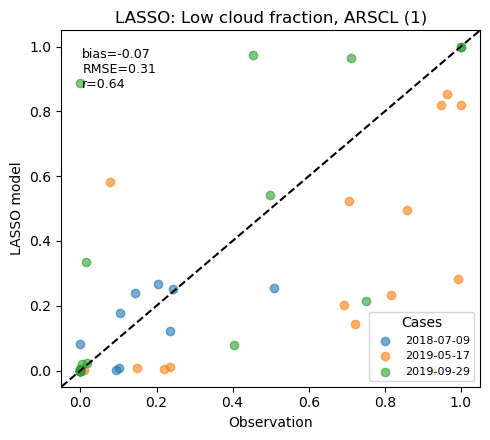

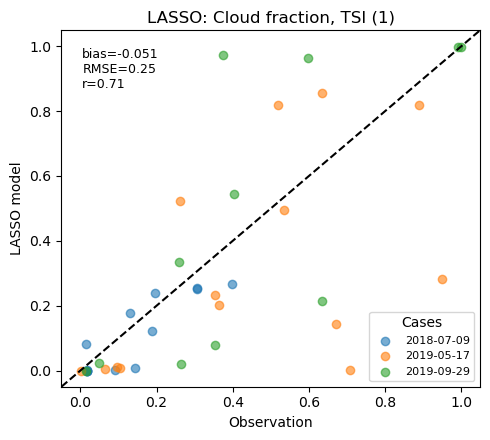

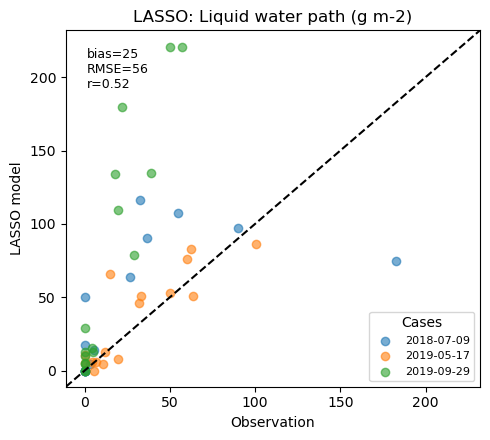

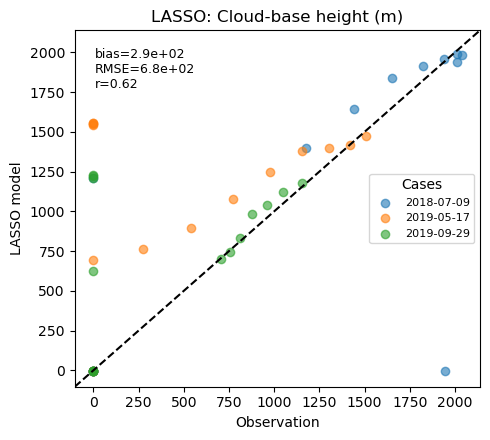

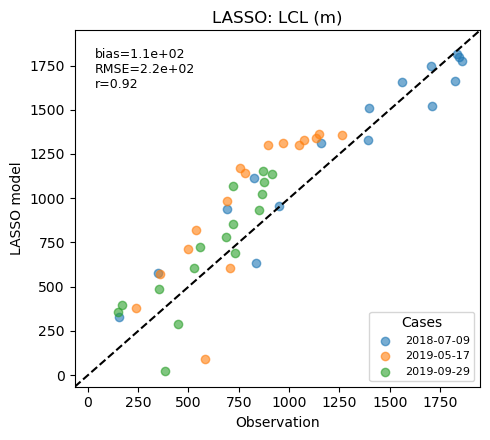

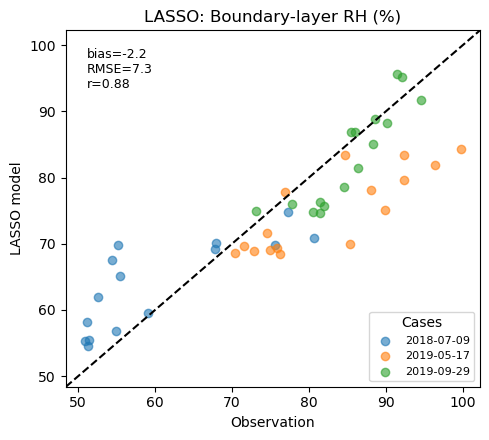

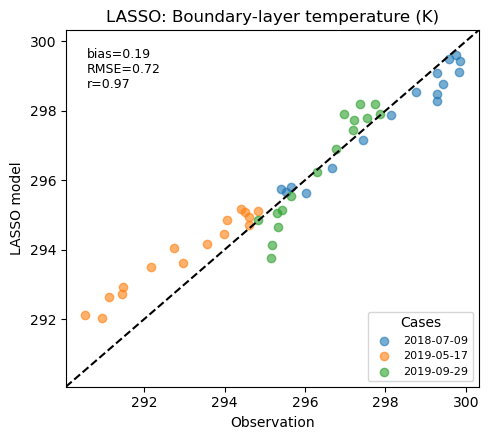

In [38]:
plot_model_obs_scatter_separate()

In [39]:
import glob
import xarray as xr
import os

pre_path = "/data/project/ARM_Summer_School_2026/data/modeling/dpscream/"

patterns = [
    "*2018-07-09*fullfield.AVERAGE.nhours_x1*.nc",
    "*2019-05-17*fullfield.AVERAGE.nhours_x1*.nc",
    "*2019-09-29*fullfield.AVERAGE.nhours_x1*.nc",
]

data_paths = []

for pattern in patterns:
    files = sorted(glob.glob(os.path.join(pre_path, pattern)))

    print(pattern)
    print(files)

    if len(files) == 0:
        raise FileNotFoundError(f"No file found for pattern: {pattern}")

    data_paths.append(files[0])

dates = ["2018-07-09", "2019-05-17", "2019-09-29"]

ds_all = xr.open_mfdataset(
    data_paths,
    combine="nested",
    concat_dim=xr.DataArray(dates, dims="date", name="date"),
)

ds_all

*2018-07-09*fullfield.AVERAGE.nhours_x1*.nc
['/data/project/ARM_Summer_School_2026/data/modeling/dpscream/scream_dpxx_LASSO_SGP_2018-07-09.fullfield.AVERAGE.nhours_x1.2018-07-09-43200.nc']
*2019-05-17*fullfield.AVERAGE.nhours_x1*.nc
['/data/project/ARM_Summer_School_2026/data/modeling/dpscream/scream_dpxx_LASSO_SGP_2019-05-17.fullfield.AVERAGE.nhours_x1.2019-05-17-43200.nc']
*2019-09-29*fullfield.AVERAGE.nhours_x1*.nc
['/data/project/ARM_Summer_School_2026/data/modeling/dpscream/scream_dpxx_LASSO_SGP_2019-09-29.fullfield.AVERAGE.nhours_x1.2019-09-29-43200.nc']


<xarray.Dataset> Size: 314MB
Dimensions:                          (date: 3, time: 45, dim2: 2, ncol: 100,
                                      lev: 128, ilev: 129, lwband: 16,
                                      swband: 14)
Coordinates:
  * time                             (time) datetime64[ns] 360B 2018-07-09T13...
  * ilev                             (ilev) float32 516B 2.255 2.905 ... 1e+03
  * lev                              (lev) float32 512B 2.58 3.23 ... 998.5
  * lwband                           (lwband) float32 64B 130.0 ... 2.965e+03
  * swband                           (swband) float32 56B 1.75e+03 ... 4.4e+04
    lat                              (ncol) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
    lon                              (ncol) float32 400B dask.array<chunksize=(100,), meta=np.ndarray>
  * date                             (date) <U10 120B '2018-07-09' ... '2019-...
Dimensions without coordinates: dim2, ncol
Data variables: (12/99)
    time_bnds                        (date, time, dim2) datetime64[ns] 2kB dask.array<chunksize=(1, 15, 2), meta=np.ndarray>
    z_mid                            (date, time, ncol, lev) float32 7MB dask.array<chunksize=(1, 15, 100, 128), meta=np.ndarray>
    p_mid                            (date, time, ncol, lev) float32 7MB dask.array<chunksize=(1, 15, 100, 128), meta=np.ndarray>
    ps                               (date, time, ncol) float32 54kB dask.array<chunksize=(1, 15, 100), meta=np.ndarray>
    omega                            (date, time, ncol, lev) float32 7MB dask.array<chunksize=(1, 15, 100, 128), meta=np.ndarray>
    cldfrac_liq                      (date, time, ncol, lev) float32 7MB dask.array<chunksize=(1, 15, 100, 128), meta=np.ndarray>
    ...                               ...
    hyai                             (date, ilev) float32 2kB dask.array<chunksize=(1, 129), meta=np.ndarray>
    hyam                             (date, lev) float32 2kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    hybi                             (date, ilev) float32 2kB dask.array<chunksize=(1, 129), meta=np.ndarray>
    hybm                             (date, lev) float32 2kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    lwband_bounds                    (date, lwband, dim2) float32 384B dask.array<chunksize=(1, 16, 2), meta=np.ndarray>
    swband_bounds                    (date, swband, dim2) float32 336B dask.array<chunksize=(1, 14, 2), meta=np.ndarray>
Attributes: (12/22)
    case_t0:                      2018-07-09-43200
    run_t0:                       2018-07-09-43200
    averaging_type:               AVERAGE
    averaging_frequency_units:    nhours
    averaging_frequency:          1
    file_max_storage_type:        num_snapshots
    ...                           ...
    contact:                      e3sm-data-support@llnl.gov
    institution_id:               E3SM-Project
    realm:                        atmos
    history:                      created on Thu Apr 23 10:33:17 2026
    Conventions:                  CF-1.8
    product:                      model-output

In [45]:
# ============================================================
# DPSCREAM vs observation scatter
# Color points by cases
# ============================================================

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


CASE_NAMES = [
    "2018-07-09",
    "2019-05-17",
    "2019-09-29",
]

ds_dpscream = ds_all


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def is_datetime_like(x):
    arr = np.asarray(x)
    return np.issubdtype(arr.dtype, np.datetime64) or isinstance(x, pd.DatetimeIndex)


def get_case_time_from_dpscream(ds, date_i):
    """
    Return DPSCREAM time coordinate for one case.
    Works for both:
        time(time)
    and
        time(date, time)
    """
    if "time" in ds.coords:
        t = ds["time"]
    elif "time" in ds:
        t = ds["time"]
    else:
        nt = ds.sizes["time"]
        return np.arange(nt)

    if "date" in t.dims:
        t = t.isel(date=date_i)

    return np.asarray(t.values).ravel()


def finite_pair_aligned(t_obs, y_obs, t_mod, y_mod, tolerance="45min"):
    """
    Pair observation and model data.

    If both time arrays are datetime-like, match obs to model times
    using nearest-neighbor matching.

    Otherwise, fall back to finite_pair(), which pairs by index.
    """
    y_obs = np.asarray(y_obs, dtype=float).ravel()
    y_mod = np.asarray(y_mod, dtype=float).ravel()

    try:
        if is_datetime_like(t_obs) and is_datetime_like(t_mod):
            t_obs = pd.to_datetime(np.asarray(t_obs).ravel())
            t_mod = pd.to_datetime(np.asarray(t_mod).ravel())

            if len(t_obs) == len(y_obs) and len(t_mod) == len(y_mod):
                obs_s = pd.Series(y_obs, index=t_obs)
                mod_s = pd.Series(y_mod, index=t_mod)

                obs_s = obs_s.sort_index().groupby(level=0).mean()
                mod_s = mod_s.sort_index().groupby(level=0).mean()

                tol = None if tolerance is None else pd.Timedelta(tolerance)

                obs_match = obs_s.reindex(
                    mod_s.index,
                    method="nearest",
                    tolerance=tol,
                )

                return finite_pair(obs_match.values, mod_s.values)

    except Exception:
        pass

    return finite_pair(y_obs, y_mod)


def boundary_layer_mean(da, ds_case, fallback_top_m=1000.0):
    """
    Boundary-layer mean.

    Primary method:
        mean below pbl_height

    Fallback:
        mean below fallback_top_m
    """
    z = ds_case["z_mid"]

    if "pbl_height" in ds_case:
        pblh = ds_case["pbl_height"]

        mask_pbl = (z >= 0.0) & (z <= pblh)
        y_pbl = da.where(mask_pbl).mean(dim=["ncol", "lev"], skipna=True)

        mask_fixed = (z >= 0.0) & (z <= fallback_top_m)
        y_fixed = da.where(mask_fixed).mean(dim=["ncol", "lev"], skipna=True)

        y = y_pbl.fillna(y_fixed)

    else:
        mask_fixed = (z >= 0.0) & (z <= fallback_top_m)
        y = da.where(mask_fixed).mean(dim=["ncol", "lev"], skipna=True)

    return y


def diagnose_lcl_from_dpscream(ds_case):
    """
    Approximate LCL height from T_2m, qv_2m, and ps.

    Output unit:
        meters

    Assumption:
        qv_2m is water-vapor mixing ratio or close to kg/kg humidity.
    """
    T = ds_case["T_2m"]      # K
    qv = ds_case["qv_2m"]    # kg/kg
    p = ds_case["ps"]        # Pa

    eps = 0.622

    # Vapor pressure.
    # If qv is mixing ratio r:
    #     e = p r / (eps + r)
    e = p * qv / (eps + qv)
    e = e.clip(min=1.0)

    # Dewpoint from Magnus formula
    log_ratio = np.log(e / 611.2)
    Td_C = 243.5 * log_ratio / (17.67 - log_ratio)
    Td_K = Td_C + 273.15

    # Dewpoint should not exceed temperature
    Td_K = xr.where(Td_K > T, T, Td_K)

    # Bolton-style LCL temperature
    Tlcl = 1.0 / (1.0 / (Td_K - 56.0) + np.log(T / Td_K) / 800.0) + 56.0

    # Convert temperature difference to height
    z_lcl = (T - Tlcl) / 0.0098
    z_lcl = z_lcl.clip(min=0.0)

    return z_lcl


def extract_dpscream_timeseries(
    varname,
    date_i,
    ds=None,
    low_cloud_top_m=5000.0,
    cloud_threshold=0.01,
):
    """
    Convert DPSCREAM variables to observation-like 1D time series.

    Supported observation variables:

        low_cloud_fraction_arscl
        cloud_fraction_tsi
        lwp
        cloud_base_height
        lcl
        rh_boundary_layer
        temperature_boundary_layer
    """
    if ds is None:
        ds = ds_dpscream

    ds_case = ds.isel(date=date_i) if "date" in ds.dims else ds
    time = get_case_time_from_dpscream(ds, date_i)

    if varname == "low_cloud_fraction_arscl":
        cf = ds_case["cldfrac_tot_for_analysis"]
        z = ds_case["z_mid"]

        mask = (z >= 0.0) & (z <= low_cloud_top_m)

        # column low-cloud fraction, then horizontal mean
        y = cf.where(mask).max(dim="lev", skipna=True).mean(dim="ncol", skipna=True)

    elif varname == "cloud_fraction_tsi":
        cf = ds_case["cldfrac_tot_for_analysis"]

        # total column cloud fraction approximation
        y = cf.max(dim="lev", skipna=True).mean(dim="ncol", skipna=True)

    elif varname == "lwp":
        y = ds_case["LiqWaterPath"].mean(dim="ncol", skipna=True)

    elif varname == "cloud_base_height":
        cf = ds_case["cldfrac_tot_for_analysis"]
        z = ds_case["z_mid"]

        mask = (
            (z >= 0.0)
            & (z <= low_cloud_top_m)
            & (cf >= cloud_threshold)
        )

        # First cloudy model level in each column, then horizontal mean
        y = z.where(mask).min(dim="lev", skipna=True).mean(dim="ncol", skipna=True)

    elif varname == "lcl":
        z_lcl = diagnose_lcl_from_dpscream(ds_case)
        y = z_lcl.mean(dim="ncol", skipna=True)

    elif varname == "rh_boundary_layer":
        rh = ds_case["RelativeHumidity"]
        y = boundary_layer_mean(rh, ds_case)

    elif varname == "temperature_boundary_layer":
        temp = ds_case["T_mid"]
        y = boundary_layer_mean(temp, ds_case)

    else:
        raise KeyError(f"No DPSCREAM diagnostic has been defined for {varname}")

    return time, np.asarray(y.load().values).ravel()


def infer_model_unit_transform(varname, obs, mod):
    """
    Infer simple unit conversion for model data so that it matches obs.

    Returns:
        scale, offset, note

    model_converted = model * scale + offset
    """
    obs = np.asarray(obs, dtype=float)
    mod = np.asarray(mod, dtype=float)

    obs_f = obs[np.isfinite(obs)]
    mod_f = mod[np.isfinite(mod)]

    if len(obs_f) == 0 or len(mod_f) == 0:
        return 1.0, 0.0, ""

    obs_p95 = np.nanpercentile(np.abs(obs_f), 95)
    mod_p95 = np.nanpercentile(np.abs(mod_f), 95)

    obs_med = np.nanmedian(obs_f)
    mod_med = np.nanmedian(mod_f)

    v = varname.lower()

    # cloud fraction: fraction <-> percent
    if "cloud_fraction" in v:
        if obs_p95 > 2.0 and mod_p95 <= 1.5:
            return 100.0, 0.0, "model cloud fraction converted from fraction to percent"
        if obs_p95 <= 1.5 and mod_p95 > 2.0:
            return 0.01, 0.0, "model cloud fraction converted from percent to fraction"

    # relative humidity: fraction <-> percent
    if "rh" in v or "relativehumidity" in v:
        if obs_p95 > 2.0 and mod_p95 <= 1.5:
            return 100.0, 0.0, "model RH converted from fraction to percent"
        if obs_p95 <= 1.5 and mod_p95 > 2.0:
            return 0.01, 0.0, "model RH converted from percent to fraction"

    # LWP: kg m-2 <-> g m-2
    if v == "lwp":
        if obs_p95 > 10.0 and mod_p95 < 5.0:
            return 1000.0, 0.0, "model LWP converted from kg m-2 to g m-2"
        if obs_p95 < 5.0 and mod_p95 > 10.0:
            return 0.001, 0.0, "model LWP converted from g m-2 to kg m-2"

    # temperature: K <-> Celsius
    if "temperature" in v:
        if obs_med < 100.0 and mod_med > 150.0:
            return 1.0, -273.15, "model temperature converted from K to degC"
        if obs_med > 150.0 and mod_med < 100.0:
            return 1.0, 273.15, "model temperature converted from degC to K"

    # height: m <-> km
    if "height" in v or v == "lcl":
        if obs_p95 < 20.0 and mod_p95 > 100.0:
            return 0.001, 0.0, "model height converted from m to km"
        if obs_p95 > 100.0 and mod_p95 < 20.0:
            return 1000.0, 0.0, "model height converted from km to m"

    return 1.0, 0.0, ""


def collect_obs_dpscream_pairs_by_case(
    varname,
    ds=None,
    case_names=CASE_NAMES,
    tolerance="45min",
    auto_units=True,
):
    """
    Collect paired obs/DPSCREAM values for each case.
    """
    if ds is None:
        ds = ds_dpscream

    n_obs_dates = get_n_dates()
    n_mod_dates = ds.sizes["date"] if "date" in ds.dims else 1
    n_dates = min(n_obs_dates, n_mod_dates, len(case_names))

    pairs_by_case = []

    for i in range(n_dates):

        t_obs, y_obs = extract_timeseries(OBS_NAME, varname, i)

        try:
            t_mod, y_mod = extract_dpscream_timeseries(varname, i, ds=ds)
        except KeyError as e:
            print(e)
            continue

        if y_obs is None or y_mod is None:
            continue

        obs, mod = finite_pair_aligned(
            t_obs,
            y_obs,
            t_mod,
            y_mod,
            tolerance=tolerance,
        )

        if len(obs) > 0:
            pairs_by_case.append((i, obs, mod))

    unit_note = ""

    if auto_units and len(pairs_by_case) > 0:
        obs_all = np.concatenate([p[1] for p in pairs_by_case])
        mod_all = np.concatenate([p[2] for p in pairs_by_case])

        scale, offset, unit_note = infer_model_unit_transform(varname, obs_all, mod_all)

        pairs_by_case = [
            (i, obs, mod * scale + offset)
            for i, obs, mod in pairs_by_case
        ]

    return pairs_by_case, unit_note


def _calc_metrics_safe(obs, mod):
    try:
        return calc_metrics(obs, mod)
    except NameError:
        bias = np.nanmean(mod - obs)
        rmse = np.sqrt(np.nanmean((mod - obs) ** 2))

        if len(obs) > 1:
            corr = np.corrcoef(obs, mod)[0, 1]
        else:
            corr = np.nan

        return {
            "bias": bias,
            "rmse": rmse,
            "corr": corr,
        }


def _variable_label_safe(varname):
    try:
        return variable_label(varname)
    except NameError:
        return varname.replace("_", " ")


def _save_or_show_safe(fig, filename):
    try:
        save_or_show(fig, filename)
    except NameError:
        fig.savefig(filename, dpi=150, bbox_inches="tight")
        plt.show()


def plot_dpscream_obs_scatter_separate(
    variables=(
        "low_cloud_fraction_arscl",
        "cloud_fraction_tsi",
        "lwp",
        "cloud_base_height",
        "lcl",
        "rh_boundary_layer",
        "temperature_boundary_layer",
    ),
    ds=None,
    case_names=CASE_NAMES,
    filename_prefix="fig06_dpscream_vs_obs_scatter",
    tolerance="45min",
    auto_units=True,
):
    """
    Plot one scatter figure for each variable:
        x-axis: observation
        y-axis: DPSCREAM

    Points are colored by case.
    """
    if ds is None:
        ds = ds_dpscream

    for varname in variables:

        pairs_by_case, unit_note = collect_obs_dpscream_pairs_by_case(
            varname,
            ds=ds,
            case_names=case_names,
            tolerance=tolerance,
            auto_units=auto_units,
        )

        fig, ax = plt.subplots(figsize=(5.2, 4.7))

        if len(pairs_by_case) == 0:
            ax.text(
                0.5,
                0.5,
                f"{varname}\nnot available",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )

        else:
            obs_all = []
            mod_all = []

            for case_i, obs, mod in pairs_by_case:

                if case_i < len(case_names):
                    case_label = case_names[case_i]
                else:
                    case_label = f"case {case_i + 1}"

                ax.scatter(
                    obs,
                    mod,
                    alpha=0.65,
                    label=case_label,
                )

                obs_all.append(obs)
                mod_all.append(mod)

            obs_all = np.concatenate(obs_all)
            mod_all = np.concatenate(mod_all)

            lo = np.nanmin([np.nanmin(obs_all), np.nanmin(mod_all)])
            hi = np.nanmax([np.nanmax(obs_all), np.nanmax(mod_all)])

            if np.isfinite(lo) and np.isfinite(hi) and lo != hi:
                pad = 0.05 * (hi - lo)
                lo -= pad
                hi += pad

                ax.plot([lo, hi], [lo, hi], linestyle="--", color="k")
                ax.set_xlim(lo, hi)
                ax.set_ylim(lo, hi)

            metrics = _calc_metrics_safe(obs_all, mod_all)

            text = (
                f"bias={metrics['bias']:.2g}\n"
                f"RMSE={metrics['rmse']:.2g}\n"
                f"r={metrics['corr']:.2g}"
            )

            if unit_note != "":
                text += f"\n{unit_note}"

            ax.text(
                0.05,
                0.95,
                text,
                transform=ax.transAxes,
                va="top",
                fontsize=8,
            )

            ax.legend(title="Cases", fontsize=8)

        ax.set_title(f"DP-SCREAM: {_variable_label_safe(varname)}")
        ax.set_xlabel("observation")
        ax.set_ylabel("DP-SCREAM")

        fig.tight_layout()

        safe_var = str(varname).replace("/", "_").replace(" ", "_")
        filename = f"{filename_prefix}_{safe_var}.png"

        _save_or_show_safe(fig, filename)
        plt.close(fig)

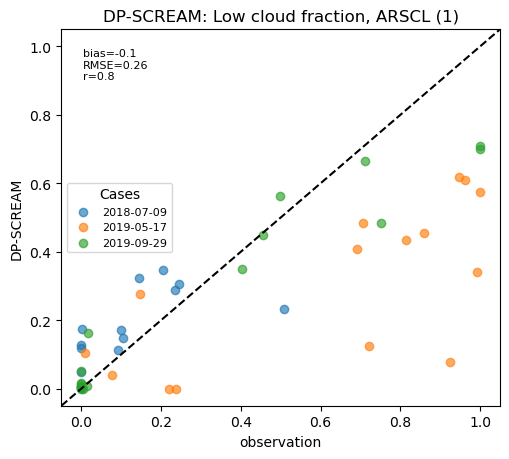

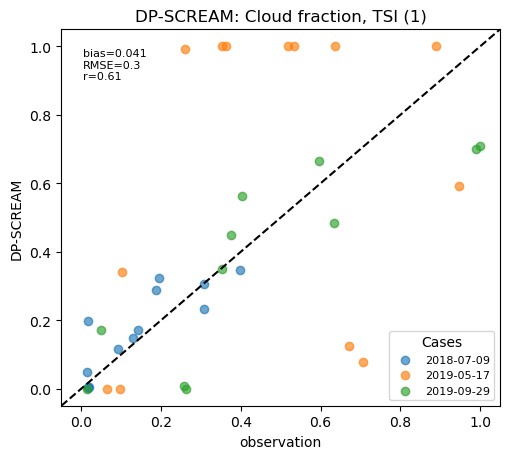

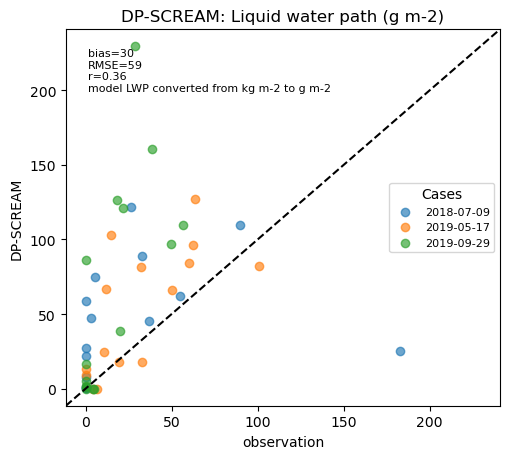

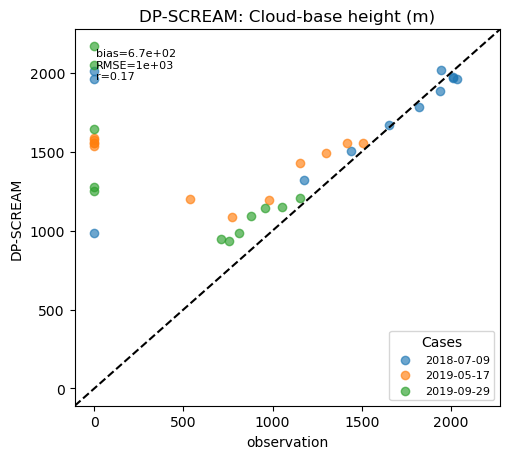

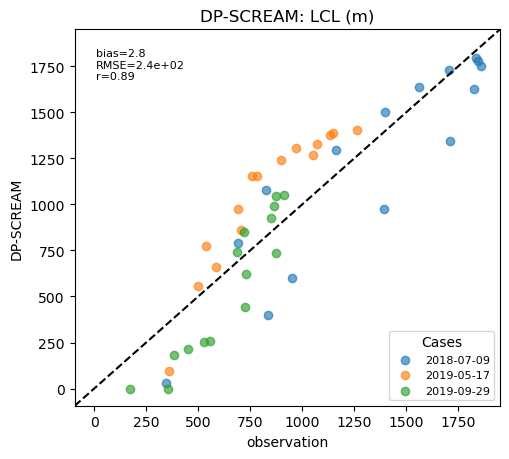

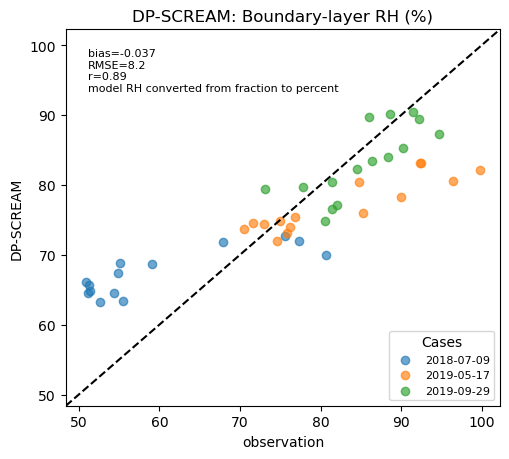

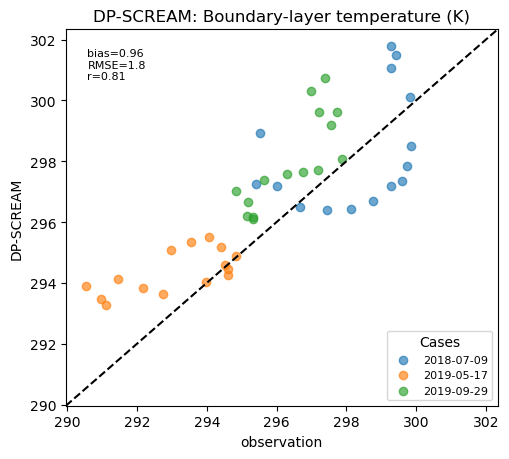

In [46]:
plot_dpscream_obs_scatter_separate()

In [49]:
# ============================================================
# WRF/LASSO and DP-SCREAM vs observation
# Same scatter plot
# Cases combined
# Model types colored differently
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Helper: check datetime
# ------------------------------------------------------------

def is_datetime_like(x):
    arr = np.asarray(x)
    return np.issubdtype(arr.dtype, np.datetime64) or isinstance(x, pd.DatetimeIndex)


# ------------------------------------------------------------
# Helper: pair obs/model by time if possible
# otherwise pair by index
# ------------------------------------------------------------

def finite_pair_aligned_or_index(t_obs, y_obs, t_mod, y_mod, tolerance="45min"):
    y_obs = np.asarray(y_obs, dtype=float).ravel()
    y_mod = np.asarray(y_mod, dtype=float).ravel()

    try:
        if is_datetime_like(t_obs) and is_datetime_like(t_mod):

            t_obs = pd.to_datetime(np.asarray(t_obs).ravel())
            t_mod = pd.to_datetime(np.asarray(t_mod).ravel())

            if len(t_obs) == len(y_obs) and len(t_mod) == len(y_mod):

                obs_s = pd.Series(y_obs, index=t_obs)
                mod_s = pd.Series(y_mod, index=t_mod)

                obs_s = obs_s.sort_index().groupby(level=0).mean()
                mod_s = mod_s.sort_index().groupby(level=0).mean()

                tol = None if tolerance is None else pd.Timedelta(tolerance)

                obs_match = obs_s.reindex(
                    mod_s.index,
                    method="nearest",
                    tolerance=tol,
                )

                return finite_pair(obs_match.values, mod_s.values)

    except Exception:
        pass

    return finite_pair(y_obs, y_mod)


# ------------------------------------------------------------
# Optional unit conversion
# Uses infer_model_unit_transform() if you already defined it
# ------------------------------------------------------------

def apply_unit_transform_if_available(varname, obs, mod, auto_units=True):
    if not auto_units:
        return mod, ""

    if "infer_model_unit_transform" not in globals():
        return mod, ""

    scale, offset, note = infer_model_unit_transform(varname, obs, mod)
    mod_new = mod * scale + offset

    return mod_new, note


# ------------------------------------------------------------
# Collect WRF/LASSO data across all cases
# ------------------------------------------------------------

def collect_obs_wrf_pairs_all_cases(
    varname,
    wrf_model_names=None,
    tolerance="45min",
    auto_units=True,
):
    """
    Collect all obs-WRF/LASSO pairs across all cases.

    All cases are merged together.
    """
    if wrf_model_names is None:
        wrf_model_names = MODEL_NAMES

    if isinstance(wrf_model_names, str):
        wrf_model_names = [wrf_model_names]

    obs_all = []
    wrf_all = []

    n_dates = get_n_dates()

    for model_name in wrf_model_names:
        for i in range(n_dates):

            t_obs, y_obs = extract_timeseries(OBS_NAME, varname, i)
            t_wrf, y_wrf = extract_timeseries(model_name, varname, i)

            if y_obs is None or y_wrf is None:
                continue

            obs, wrf = finite_pair_aligned_or_index(
                t_obs,
                y_obs,
                t_wrf,
                y_wrf,
                tolerance=tolerance,
            )

            if len(obs) > 0:
                obs_all.append(obs)
                wrf_all.append(wrf)

    if len(obs_all) == 0:
        return None, None, ""

    obs_all = np.concatenate(obs_all)
    wrf_all = np.concatenate(wrf_all)

    wrf_all, unit_note = apply_unit_transform_if_available(
        varname,
        obs_all,
        wrf_all,
        auto_units=auto_units,
    )

    return obs_all, wrf_all, unit_note


# ------------------------------------------------------------
# Collect DP-SCREAM data across all cases
# ------------------------------------------------------------

def collect_obs_dpscream_pairs_all_cases(
    varname,
    ds_dpscream=None,
    tolerance="45min",
    auto_units=True,
):
    """
    Collect all obs-DP-SCREAM pairs across all cases.

    All cases are merged together.
    """
    if ds_dpscream is None:
        if "ds_dpscream" in globals():
            ds_dpscream = globals()["ds_dpscream"]
        elif "ds_all" in globals():
            ds_dpscream = globals()["ds_all"]
        else:
            raise ValueError("Please provide ds_dpscream or define ds_all first.")

    obs_all = []
    dps_all = []

    n_obs_dates = get_n_dates()
    n_dps_dates = ds_dpscream.sizes["date"] if "date" in ds_dpscream.dims else 1

    n_dates = min(n_obs_dates, n_dps_dates)

    for i in range(n_dates):

        t_obs, y_obs = extract_timeseries(OBS_NAME, varname, i)

        try:
            t_dps, y_dps = extract_dpscream_timeseries(
                varname,
                i,
                ds=ds_dpscream,
            )
        except Exception as e:
            print(f"DP-SCREAM diagnostic failed for {varname}, case {i}: {e}")
            continue

        if y_obs is None or y_dps is None:
            continue

        obs, dps = finite_pair_aligned_or_index(
            t_obs,
            y_obs,
            t_dps,
            y_dps,
            tolerance=tolerance,
        )

        if len(obs) > 0:
            obs_all.append(obs)
            dps_all.append(dps)

    if len(obs_all) == 0:
        return None, None, ""

    obs_all = np.concatenate(obs_all)
    dps_all = np.concatenate(dps_all)

    dps_all, unit_note = apply_unit_transform_if_available(
        varname,
        obs_all,
        dps_all,
        auto_units=auto_units,
    )

    return obs_all, dps_all, unit_note


# ------------------------------------------------------------
# Safe wrappers
# ------------------------------------------------------------

def calc_metrics_safe(obs, mod):
    try:
        return calc_metrics(obs, mod)
    except NameError:
        bias = np.nanmean(mod - obs)
        rmse = np.sqrt(np.nanmean((mod - obs) ** 2))

        if len(obs) > 1:
            corr = np.corrcoef(obs, mod)[0, 1]
        else:
            corr = np.nan

        return {
            "bias": bias,
            "rmse": rmse,
            "corr": corr,
        }


def variable_label_safe(varname):
    try:
        return variable_label(varname)
    except NameError:
        return varname.replace("_", " ")


def save_or_show_safe(fig, filename):
    try:
        save_or_show(fig, filename)
    except NameError:
        fig.savefig(filename, dpi=150, bbox_inches="tight")
        plt.show()


# ------------------------------------------------------------
# Main plotting function
# ------------------------------------------------------------

def plot_wrf_dpscream_obs_scatter_same_axes(
    variables=(
        "low_cloud_fraction_arscl",
        "cloud_fraction_tsi",
        "lwp",
        "cloud_base_height",
        "lcl",
        "rh_boundary_layer",
        "temperature_boundary_layer",
    ),
    wrf_model_names=None,
    ds_dpscream=None,
    filename_prefix="fig_wrf_dpscream_vs_obs_scatter",
    tolerance="45min",
    auto_units=True,
    wrf_color="tab:blue",
    dpscream_color="tab:orange",
):
    """
    Plot WRF/LASSO and DP-SCREAM against observation on the same axes.

    All cases are combined.

    WRF/LASSO:
        one color

    DP-SCREAM:
        another color
    """
    for varname in variables:

        obs_wrf, wrf, wrf_unit_note = collect_obs_wrf_pairs_all_cases(
            varname,
            wrf_model_names=wrf_model_names,
            tolerance=tolerance,
            auto_units=auto_units,
        )

        obs_dps, dps, dps_unit_note = collect_obs_dpscream_pairs_all_cases(
            varname,
            ds_dpscream=ds_dpscream,
            tolerance=tolerance,
            auto_units=auto_units,
        )

        fig, ax = plt.subplots(figsize=(5.4, 4.8))

        all_values = []

        # --------------------------
        # WRF/LASSO scatter
        # --------------------------
        if obs_wrf is not None and wrf is not None:
            ax.scatter(
                obs_wrf,
                wrf,
                alpha=0.55,
                s=24,
                color=wrf_color,
                marker="o",
                label=f"LASSO, n={len(obs_wrf)}",
            )

            all_values.append(obs_wrf)
            all_values.append(wrf)

        # --------------------------
        # DP-SCREAM scatter
        # --------------------------
        if obs_dps is not None and dps is not None:
            ax.scatter(
                obs_dps,
                dps,
                alpha=0.55,
                s=24,
                color=dpscream_color,
                marker="^",
                label=f"DP-SCREAM, n={len(obs_dps)}",
            )

            all_values.append(obs_dps)
            all_values.append(dps)

        # --------------------------
        # No data case
        # --------------------------
        if len(all_values) == 0:
            ax.text(
                0.5,
                0.5,
                f"{varname}\nnot available",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )

        else:
            all_values = np.concatenate(all_values)

            lo = np.nanmin(all_values)
            hi = np.nanmax(all_values)

            if np.isfinite(lo) and np.isfinite(hi) and lo != hi:
                pad = 0.05 * (hi - lo)
                lo -= pad
                hi += pad

                ax.plot(
                    [lo, hi],
                    [lo, hi],
                    linestyle="--",
                    color="k",
                    linewidth=1.2,
                    label="1:1",
                )

                ax.set_xlim(lo, hi)
                ax.set_ylim(lo, hi)

            # --------------------------
            # Metrics text
            # --------------------------
            text_lines = []

            if obs_wrf is not None and wrf is not None:
                metrics_wrf = calc_metrics_safe(obs_wrf, wrf)

                text_lines.append(
                    "LASSO:"
                    f" bias={metrics_wrf['bias']:.2g},"
                    f" RMSE={metrics_wrf['rmse']:.2g},"
                    f" r={metrics_wrf['corr']:.2g}"
                )

            if obs_dps is not None and dps is not None:
                metrics_dps = calc_metrics_safe(obs_dps, dps)

                text_lines.append(
                    "DP-SCREAM:"
                    f" bias={metrics_dps['bias']:.2g},"
                    f" RMSE={metrics_dps['rmse']:.2g},"
                    f" r={metrics_dps['corr']:.2g}"
                )

            if wrf_unit_note != "":
                text_lines.append(f"WRF unit: {wrf_unit_note}")

            if dps_unit_note != "":
                text_lines.append(f"DP-SCREAM unit: {dps_unit_note}")

            ax.text(
                0.04,
                0.96,
                "\n".join(text_lines),
                transform=ax.transAxes,
                va="top",
                ha="left",
                fontsize=8,
            )

            ax.legend(fontsize=8, loc="lower right")

        ax.set_title(f"{variable_label_safe(varname)}")
        ax.set_xlabel("Observation")
        ax.set_ylabel("Model")

        fig.tight_layout()

        safe_var = str(varname).replace("/", "_").replace(" ", "_")
        filename = f"{filename_prefix}_{safe_var}.png"

        save_or_show_safe(fig, filename)
        plt.close(fig)

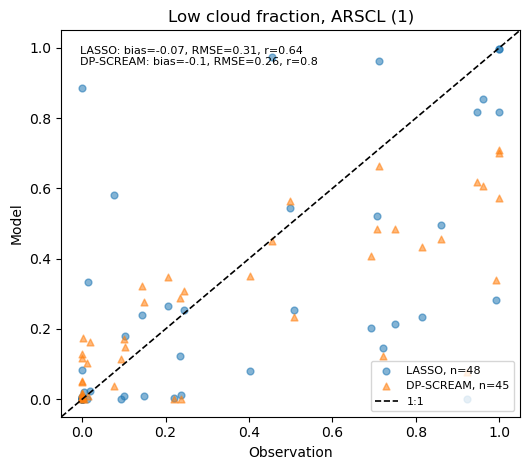

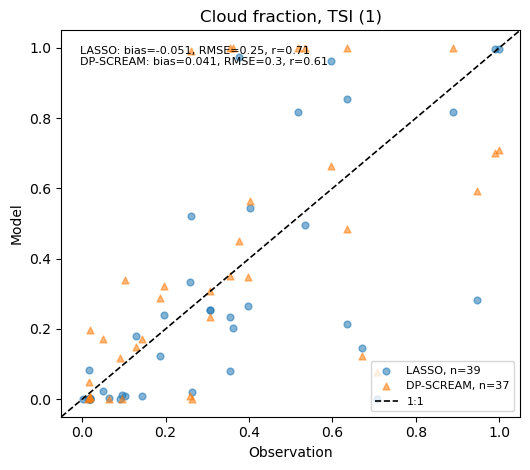

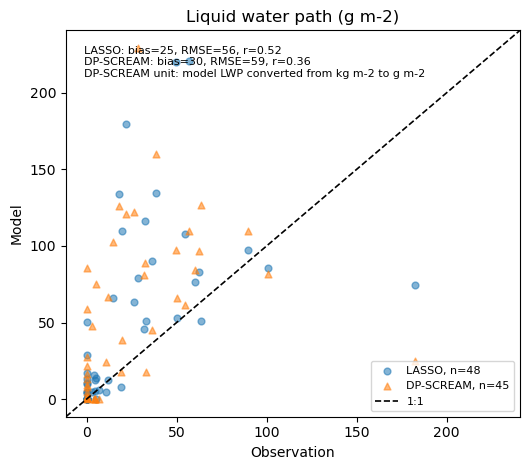

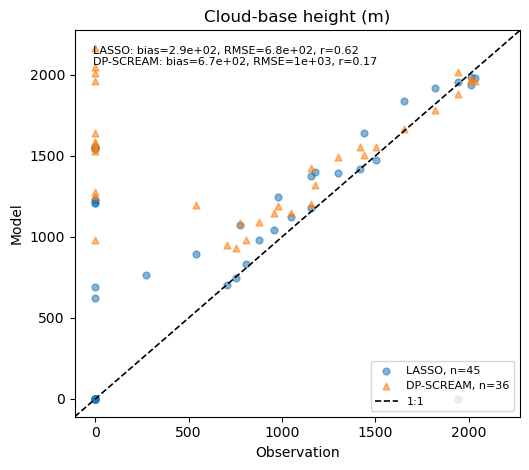

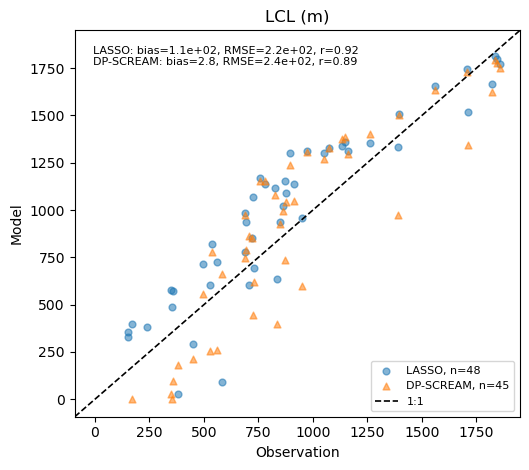

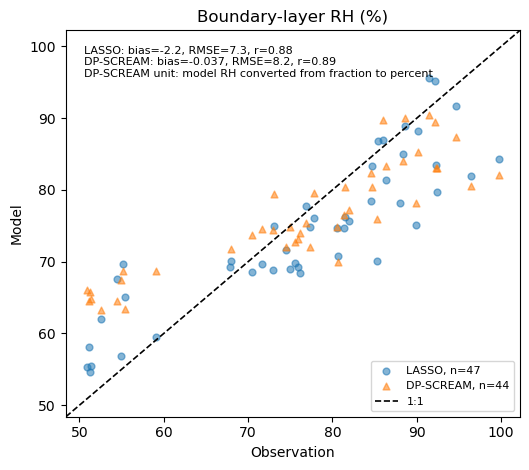

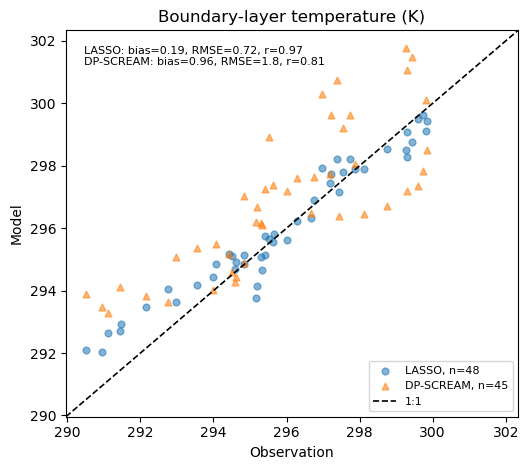

In [50]:
plot_wrf_dpscream_obs_scatter_same_axes(
    wrf_model_names=MODEL_NAMES,
    ds_dpscream=ds_all,
)